# 12 — HLLSet PageRank: the BSS lattice as a web of content, HSF as popularity

The HLLSet lattice with its **asymmetric BSS edges** is structurally the
same thing as the web: nodes (HLLSets) connected by directed,
weighted links (BSS coverage), and a per-node **popularity** signal
that on the web is page visits and here is **HSF** — HLLSet frequency
(the `HllsetLut` touch-count `TH` that `ewm-sm-explore store` already
ranks by).

Right now we navigate the lattice with the **Merkle tree**:
content-address, exact lookup. That is a dictionary, not a search
engine. This notebook does the Google move: run **PageRank** over the
BSS link graph, seeded with HSF as the teleportation prior, and use
the stationary distribution to **search related HLLSets** — the
neighbors a Merkle lookup can never surface because their content key
differs.

```text
   web                           HLLSet lattice
   page ────────────────►        HLLSet (a frame, a codebook gate, …)
   hyperlink ───────────►        BSS edge (asymmetric coverage)
   visits / popularity ─►        HSF = HllsetLut TH (touch count)
   Google PageRank ─────►        this notebook
   URL lookup ──────────►        Merkle tree (content address)
```

The demo uses the real open-loop frames of the structural-router run
(notebook 21, cache dir) plus the three per-LLM cumulative codebook
gates — a small but genuine lattice: 19 nodes, asymmetric BSS edges.

In [1]:
import json
import os

import mmh3
import numpy as np

BITS_PER_REG = 32
P = 10          # 1024 registers — the project's soldered precision

def frame_set(tokens, p=P):
    """G1 ∪ G2 ∪ G3 projection (CHANNEL_SEEDS = [0,1,2]) as a Python bitset."""
    s = 0
    m = 1 << p
    for t in tokens:
        for seed in (0, 1, 2):
            h = mmh3.hash64(t.encode(), seed=seed, signed=False)[0]
            reg = h & (m - 1)
            rem = h >> p
            tz = 31 if rem == 0 else min((rem & -rem).bit_length() - 1, 31)
            s |= 1 << (reg * BITS_PER_REG + tz)
    return s

CACHE = "/home/alexmy/.cache/ewm-structural-router"
union_path = f"{CACHE}/open_union.jsonl"
frame_path = f"{CACHE}/frame_frontends.json"
assert os.path.exists(union_path), f"run ewm-state-machine notebook 21 first: {union_path}"
assert os.path.exists(frame_path), f"missing {frame_path}"

frames = [json.loads(line) for line in open(union_path)]
frontends = json.load(open(frame_path))["dimensions"]
print("frames:", len(frames), "| codebook gates:", len(frontends))
print("hash parity check (tid0):", mmh3.hash64(b"tid0", seed=0, signed=False)[0])

frames: 16 | codebook gates: 3
hash parity check (tid0): 2892634914804110692


In [2]:
# Nodes: every step frame of the open loop + the per-LLM cumulative
# codebook gates. Each node is a bitset (Python int) over the 32768-bit
# plane; popcount = active bits.
nodes = [frame_set(f["tokens"]) for f in frames]
labels = [f"t{i:02d}" for i in range(1, len(frames) + 1)]
for d in frontends:
    nodes.append(frame_set(d["tokens"]))
    labels.append(d["name"])

n = len(nodes)
pop = np.array([int(v.bit_count()) for v in nodes], dtype=np.float64)
print("nodes:", n, "| popcounts:", {l: int(p) for l, p in zip(labels, pop)})

nodes: 19 | popcounts: {'t01': 131, 't02': 203, 't03': 204, 't04': 179, 't05': 147, 't06': 152, 't07': 184, 't08': 198, 't09': 131, 't10': 203, 't11': 204, 't12': 179, 't13': 147, 't14': 152, 't15': 184, 't16': 198, 'llm_a': 385, 'llm_b': 433, 'llm_c': 254}


## §1 — The BSS link graph (asymmetric)

`BSS(i, j) = |H_i ∩ H_j| / |H_j|` — the fraction of `H_j` covered by
`H_i`. It is asymmetric: a step frame is fully covered by its
cumulative gate (`BSS(step, gate) = 1` when the gate contains the
step), but the gate is only partly covered by the step. We read each
pair as a **directed coverage link**: `i` points at the nodes it
covers, with weight `BSS(i, j)`.

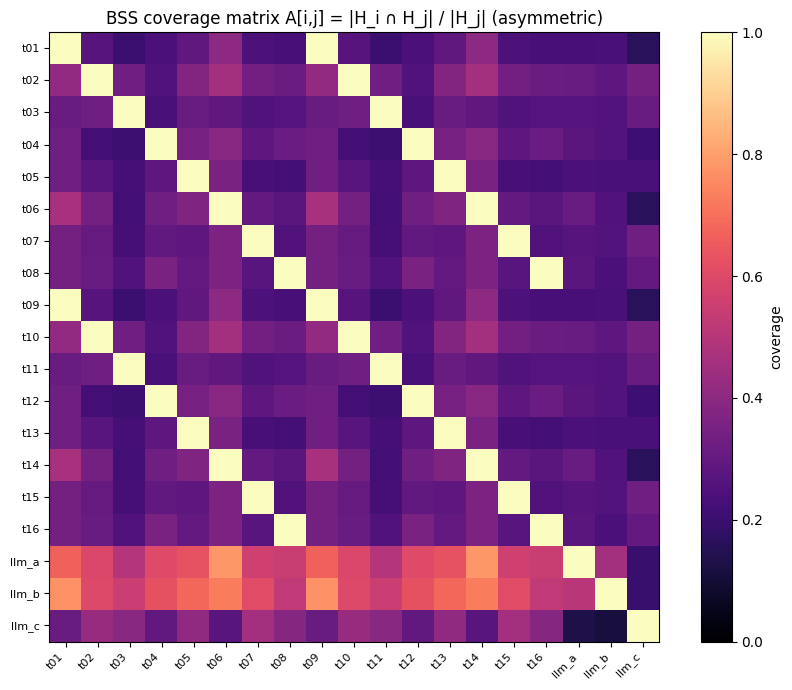

total asymmetric mass: 20.1 (0 would be a symmetric graph)


In [3]:
import matplotlib.pyplot as plt

A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        inter = int(nodes[i] & nodes[j]).bit_count()
        A[i, j] = inter / pop[j] if pop[j] else 0.0   # BSS(i covers j)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(A, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(n), labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n), labels, fontsize=8)
ax.set_title("BSS coverage matrix A[i,j] = |H_i ∩ H_j| / |H_j| (asymmetric)")
plt.colorbar(im, label="coverage")
plt.tight_layout()
plt.savefig(f"{CACHE}/bss_graph.png", dpi=110)
plt.show()

asym = np.abs(A - A.T).sum() / 2
print("total asymmetric mass:", round(float(asym), 1), "(0 would be a symmetric graph)")

## §2 — HSF: HLLSet frequency (popularity)

The analog of page visits. Here HSF is the content frequency across
the observations (how often this exact HLLSet appears); in the Rust
store the production HSF is `HllsetLut::TH` — the touch count that
`ewm-sm-explore store` ranks by. HSF is a popularity prior, not a
relatedness measure: it sees a node's own frequency, but not how
**central** it is in the coverage graph.

In [4]:
from collections import Counter

content = Counter(nodes)
hsf = np.array([content[v] for v in nodes], dtype=np.float64)
hsf_rank = np.argsort(np.argsort(-hsf))  # 0 = most frequent

order = np.argsort(-hsf)
print("HSF ranking (popularity only):")
for k in range(6):
    i = order[k]
    print(f"  {k+1}. {labels[i]:6s}  HSF={hsf[i]:.0f}  pop={pop[i]:.0f}")

HSF ranking (popularity only):
  1. t01     HSF=2  pop=131
  2. t02     HSF=2  pop=203
  3. t03     HSF=2  pop=204
  4. t04     HSF=2  pop=179
  5. t05     HSF=2  pop=147
  6. t06     HSF=2  pop=152


## §3 — PageRank over the BSS graph, seeded by HSF

The web model: each node distributes its vote among the nodes that
**cover it**, proportionally to coverage — so the transition is
`T[i, j] = BSS(i covers j) / Σ_k BSS(k covers j)`. Then
`r = d·T·r + (1-d)·v` with teleportation vector `v = HSF` normalized.
A node is important if it covers nodes that are themselves important;
HSF biases the random-surfer jumps toward popular content.

In [5]:
d = 0.85

col_sum = A.sum(axis=0)
T = np.divide(A, col_sum, out=np.zeros_like(A), where=col_sum > 0)
v = hsf / hsf.sum()

r = np.full(n, 1.0 / n)
for it in range(500):
    r_new = d * (T @ r) + (1.0 - d) * v
    if np.abs(r_new - r).max() < 1e-12:
        r = r_new
        break
    r = r_new
else:
    print("did not converge in 500 iterations")

pr_rank = np.argsort(np.argsort(-r))

def spearman(a, b):
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    return float(np.corrcoef(ra, rb)[0, 1])

print(f"converged in {it} iterations | PageRank sum {r.sum():.6f}")
print("PageRank ranking (importance over the coverage graph):")
for k in range(6):
    i = np.argsort(-r)[k]
    print(f"  {k+1}. {labels[i]:6s}  PR={r[i]:.4f}  HSF={hsf[i]:.0f}  pop={pop[i]:.0f}")
print()
print("Spearman(HSF rank, PageRank rank):", round(spearman(hsf, r), 3))
movers = [(labels[i], hsf_rank[i], pr_rank[i])
          for i in range(n) if abs(hsf_rank[i] - pr_rank[i]) >= 3]
print("nodes that move >= 3 rank positions (popularity alone mis-sorts them):")
for label, h, p in sorted(movers, key=lambda t: -abs(t[1]-t[2]))[:8]:
    print(f"  {label:6s} HSF rank {h:2d} -> PageRank rank {p:2d}")

converged in 13 iterations | PageRank sum 1.000000
PageRank ranking (importance over the coverage graph):
  1. llm_b   PR=0.0779  HSF=1  pop=433
  2. llm_a   PR=0.0744  HSF=1  pop=385
  3. t02     PR=0.0563  HSF=2  pop=203
  4. t10     PR=0.0563  HSF=2  pop=203
  5. t16     PR=0.0523  HSF=2  pop=198
  6. t08     PR=0.0523  HSF=2  pop=198

Spearman(HSF rank, PageRank rank): -0.018
nodes that move >= 3 rank positions (popularity alone mis-sorts them):
  t01    HSF rank  0 -> PageRank rank 17
  llm_b  HSF rank 17 -> PageRank rank  0
  llm_a  HSF rank 16 -> PageRank rank  1
  t05    HSF rank  4 -> PageRank rank 16
  t16    HSF rank 15 -> PageRank rank  4
  t09    HSF rank  8 -> PageRank rank 18
  t04    HSF rank  3 -> PageRank rank 12
  t06    HSF rank  5 -> PageRank rank 11


## §4 — Related-HLLSet search: Merkle (exact) vs PageRank (related)

The Merkle tree answers *"which node has exactly this content?"* — a
content-address lookup. The BSS graph answers *"which nodes are
related to this one, and how important are they?"*. For a query node
we list two relatedness views:

- **covers** — nodes the query covers (`BSS(q, ·)` high): its members,
  the content it points at;
- **covered by** — nodes covering the query (`BSS(·, q)` high): its
  hubs, the gates/categories it belongs to.

Both lists are re-ranked by PageRank, so *important* related nodes
surface first — the Google move the Merkle tree cannot make.

In [6]:
q = 0   # the first step frame ("What is the capital of France?") as query
print(f"query: {labels[q]}  (pop={pop[q]:.0f})")

# Merkle mode: exact content-address lookup.
exact = [labels[i] for i in range(n) if nodes[i] == nodes[q]]
print("Merkle exact match:", exact)

# Relatedness mode: BSS neighbors, re-ranked by PageRank.
def related(weights):
    idx = np.argsort(-weights)
    return [(labels[i], round(float(weights[i]), 3), round(float(r[i]), 4))
            for i in idx if i != q and weights[i] > 0][:4]

print()
print("covers (query -> node, BSS(q,·)):")
for label, bss, pr in related(A[q]):
    print(f"  {label:6s}  BSS={bss:.3f}  PR={pr:.4f}")
print()
print("covered by (node -> query, BSS(·,q)):")
for label, bss, pr in related(A[:, q]):
    print(f"  {label:6s}  BSS={bss:.3f}  PR={pr:.4f}")

query: t01  (pop=131)
Merkle exact match: ['t01', 't09']

covers (query -> node, BSS(q,·)):
  t09     BSS=1.000  PR=0.0442
  t14     BSS=0.401  PR=0.0506
  t06     BSS=0.401  PR=0.0506
  t05     BSS=0.293  PR=0.0460

covered by (node -> query, BSS(·,q)):
  t09     BSS=1.000  PR=0.0442
  llm_b   BSS=0.771  PR=0.0779
  llm_a   BSS=0.672  PR=0.0744
  t14     BSS=0.466  PR=0.0506


## §5 — Where this plugs into ewm-sm

- **HSF already exists**: `HllsetLut::TH` — `ewm-sm-explore store`
  prints the ranked list. It is popularity only, and the Merkle tree
  search does not consume it.
- **PageRank is a second ranking dimension** over the same nodes:
  importance in the BSS coverage graph. A natural production step is
  to persist `PR` next to `TH` in the hllsetLUT table and expose both
  in `ewm-sm-explore store` / the Arrow cache.
- **Two navigation modes coexist**: the Merkle tree (exact
  content-address) and the PageRank/BSS graph (related + important).
  A router or a context manager would use the Merkle tree to fetch a
  node and the PageRank graph to fetch *what relates to it* — the
  lattice analog of "I know the URL" vs "search the web".

The demo used 19 nodes built from the notebook-21 open loop; the same
construction scales to every HLLSet the store registers (per-frame,
per-gate, per-commit) — the `HllsetLut` is already the node registry.